In [1]:
import pandas as pd
import numpy as np

# ============================================================
# 1. PEMROSESAN DATASET
# ============================================================

file_path = 'dataset/AXA_Prepared_Data.csv'
df = pd.read_csv(file_path)
df.head()

,Claim ID,Nomor Polis,Plan Code,Plan_Level,Gender,Gender_Enc,Domisili,Tanggal Lahir,Tanggal Efektif Polis,Reimburse/Cashless,...,Policy_Tenure_Days_STD,Treatment_Duration_STD,Claim_Frequency_STD,Cost_Gap_Ratio_STD,Approval_Rate_STD,Payment_Delay_Days_STD,Cost_Per_Day_STD,Nominal Biaya RS Yang Terjadi_STD,Nominal Klaim Yang Disetujui_STD,Anomaly_Label
0,C-0001-M,POL-0176,M-001,1,F,0,JAKARTA,1967-02-20,2015-01-09,R,...,-0.270689,-0.431396,-0.183115,-0.002858,0.002860,-0.681733,-0.391590,-0.336776,-0.204150,1
1,C-0002-M,POL-3288,M-002,2,M,1,YOGYAKARTA,1956-09-25,2012-06-19,R,...,1.266679,-0.431396,-0.111066,0.017425,-0.017423,-1.273665,0.672157,0.139955,0.196746,0
2,C-0003-M,POL-1786,M-002,2,F,0,SURABAYA,1959-10-21,2015-03-16,R,...,-0.391113,-0.431396,-0.057030,0.017622,-0.017619,2.633089,2.216131,0.831905,0.970287,1
3,C-0004-M,POL-1786,M-002,2,F,0,SURABAYA,1959-10-21,2015-03-16,R,...,-0.292584,-0.431396,-0.057030,0.017334,-0.017332,-0.533750,2.196082,0.822920,1.033781,1
4,C-0005-M,POL-2778,M-002,2,F,0,JAKARTA,1968-09-06,2014-06-24,R,...,0.056178,-0.431396,-0.255163,0.017334,-0.017332,-1.924791,1.463021,0.494390,0.635959,1


In [2]:
# ============================================================
# 2. PEMROSESAN DATASET
# ============================================================

df.info()
df = df.dropna()  
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 4627 entries, 0 to 4626
Data columns (total 57 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Claim ID                           4627 non-null   str    
 1   Nomor Polis                        4627 non-null   str    
 2   Plan Code                          4627 non-null   str    
 3   Plan_Level                         4627 non-null   int64  
 4   Gender                             4627 non-null   str    
 5   Gender_Enc                         4627 non-null   int64  
 6   Domisili                           4627 non-null   str    
 7   Tanggal Lahir                      4627 non-null   str    
 8   Tanggal Efektif Polis              4627 non-null   str    
 9   Reimburse/Cashless                 4627 non-null   str    
 10  Reimburse_Enc                      4627 non-null   int64  
 11  Inpatient/Outpatient               4627 non-null   str    
 12  InP

,Claim ID,Nomor Polis,Plan Code,Plan_Level,Gender,Gender_Enc,Domisili,Tanggal Lahir,Tanggal Efektif Polis,Reimburse/Cashless,...,Policy_Tenure_Days_STD,Treatment_Duration_STD,Claim_Frequency_STD,Cost_Gap_Ratio_STD,Approval_Rate_STD,Payment_Delay_Days_STD,Cost_Per_Day_STD,Nominal Biaya RS Yang Terjadi_STD,Nominal Klaim Yang Disetujui_STD,Anomaly_Label
0,C-0001-M,POL-0176,M-001,1,F,0,JAKARTA,1967-02-20,2015-01-09,R,...,-0.270689,-0.431396,-0.183115,-0.002858,0.002860,-0.681733,-0.391590,-0.336776,-0.204150,1
1,C-0002-M,POL-3288,M-002,2,M,1,YOGYAKARTA,1956-09-25,2012-06-19,R,...,1.266679,-0.431396,-0.111066,0.017425,-0.017423,-1.273665,0.672157,0.139955,0.196746,0
2,C-0003-M,POL-1786,M-002,2,F,0,SURABAYA,1959-10-21,2015-03-16,R,...,-0.391113,-0.431396,-0.057030,0.017622,-0.017619,2.633089,2.216131,0.831905,0.970287,1
3,C-0004-M,POL-1786,M-002,2,F,0,SURABAYA,1959-10-21,2015-03-16,R,...,-0.292584,-0.431396,-0.057030,0.017334,-0.017332,-0.533750,2.196082,0.822920,1.033781,1
4,C-0005-M,POL-2778,M-002,2,F,0,JAKARTA,1968-09-06,2014-06-24,R,...,0.056178,-0.431396,-0.255163,0.017334,-0.017332,-1.924791,1.463021,0.494390,0.635959,1


In [9]:
# ============================================================
# 3. PENENTUAN BOBOT & KRITERIA
# ============================================================

# Pilih hanya kolom numerik untuk perhitungan
df_numerik = df.select_dtypes(include=[np.number])
# Contoh bobot, jumlah harus = 1 (sesuaikan jumlah dengan kolom numerik!)
bobot = [0.3, 0.2, 0.2, 0.15, 0.15] 
# 1=benefit, 0=cost
kriteria = [1, 1, 0, 1, 0]  
# Memastikan urutan bobot & kriteria sesuai urutan kolom fitur
df_matrix = df_numerik.iloc[:, :len(bobot)].values

In [ ]:
# ============================================================
# 4. TAHAPAN METODE SAW (Simple Additive Weighting)
# ============================================================

# A. Normalisasi matriks keputusan
def normalisasi_saw(matrix, kriteria):
    norm = np.zeros_like(matrix, dtype=float)
    for j in range(matrix.shape[1]):
        if kriteria[j] == 1:  # benefit
            max_val = matrix[:, j].max()
            norm[:, j] = matrix[:, j] / max_val if max_val != 0 else 0
        else:  # cost
            # Cari min yang > 0, jika tidak ada, isi 1
            min_val = matrix[:, j][matrix[:, j] > 0].min() if np.any(matrix[:, j] > 0) else 0
            col = matrix[:, j].copy()
            col[col == 0] = np.finfo(float).eps  # Hindari pembagian dengan nol
            if min_val == 0:
                norm[:, j] = 1  # Semua 0, beri skor 1
            else:
                norm[:, j] = min_val / col
    return norm

saw_norm = normalisasi_saw(df_matrix, kriteria)

# B. Mengalikan dengan bobot dan menjumlahkan
saw_skor = np.dot(saw_norm, bobot)

# C. Masukkan skor dan ranking ke DataFrame
df_saw = df.copy()
df_saw['SAW_Score'] = saw_skor
df_saw['Rank_SAW'] = df_saw['SAW_Score'].rank(ascending=False, method='min')
df_saw = df_saw.sort_values('Rank_SAW')
df_saw.head(10)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7704\154994234.py:14: RuntimeWarning: invalid value encountered in divide
  norm[:, j] = matrix[:, j].min() / col


,Claim ID,Nomor Polis,Plan Code,Plan_Level,Gender,Gender_Enc,Domisili,Tanggal Lahir,Tanggal Efektif Polis,Reimburse/Cashless,...,Claim_Frequency_STD,Cost_Gap_Ratio_STD,Approval_Rate_STD,Payment_Delay_Days_STD,Cost_Per_Day_STD,Nominal Biaya RS Yang Terjadi_STD,Nominal Klaim Yang Disetujui_STD,Anomaly_Label,SAW_Score,Rank_SAW
1125,C-1413-M,POL-1707,M-003,3,M,1,SURABAYA,1961-11-22,2016-05-20,R,...,-0.489321,0.018284,-0.018282,-0.504153,-0.372931,-0.328413,-0.369916,0,0.65,1.0
1107,C-1395-M,POL-1567,M-003,3,M,1,JAKARTA,1950-09-13,2016-08-28,R,...,-0.291188,0.017629,-0.017626,0.058183,-0.346446,-0.257856,-0.282350,0,0.65,1.0
4406,C-5488-M,POL-1450,M-003,3,M,1,SURABAYA,1951-09-11,2012-07-27,R,...,-0.453297,0.017603,-0.017601,-1.332859,-0.387540,-0.093334,-0.091979,0,0.65,1.0
1075,C-1363-M,POL-3297,M-003,3,M,1,YOGYAKARTA,1951-02-03,2012-10-17,R,...,-0.453297,0.019165,-0.019162,-0.622540,-0.337844,-0.062518,-0.161040,0,0.65,1.0
1459,C-1874-M,POL-2345,M-003,3,M,1,JAKARTA,1945-05-13,2012-09-28,R,...,-0.417272,0.017473,-0.017471,-0.060204,-0.302579,-0.296884,-0.324540,0,0.65,1.0
1057,C-1345-M,POL-1567,M-003,3,M,1,JAKARTA,1950-09-13,2016-08-28,R,...,-0.291188,0.017334,-0.017332,-0.800119,-0.469507,-0.371695,-0.412798,1,0.65,1.0
1067,C-1355-M,POL-1567,M-003,3,M,1,JAKARTA,1950-09-13,2016-08-28,R,...,-0.291188,0.017334,-0.017332,-1.540035,-0.469507,-0.371695,-0.412798,1,0.65,1.0
1448,C-1863-M,POL-0087,M-003,3,M,1,TANGERANG,1978-05-08,2012-03-14,R,...,-0.489321,0.017357,-0.017354,-1.007296,0.696242,0.150749,0.217298,0,0.65,1.0
1382,C-1795-M,POL-1373,M-003,3,M,1,SURABAYA,2015-10-23,2016-02-05,R,...,-0.471309,0.017397,-0.017395,-0.622540,-0.422757,-0.179328,-0.182492,0,0.65,1.0
1487,C-1902-M,POL-3297,M-003,3,M,1,YOGYAKARTA,1951-02-03,2012-10-17,R,...,-0.453297,0.022464,-0.022462,1.981963,-0.327408,-0.173572,-0.394532,0,0.65,1.0


Tabel Keputusan SAW (10 teratas)


,Claim ID,Nomor Polis,Plan Code,Plan_Level,Gender,Gender_Enc,Domisili,Tanggal Lahir,Tanggal Efektif Polis,Reimburse/Cashless,...,Claim_Frequency_STD,Cost_Gap_Ratio_STD,Approval_Rate_STD,Payment_Delay_Days_STD,Cost_Per_Day_STD,Nominal Biaya RS Yang Terjadi_STD,Nominal Klaim Yang Disetujui_STD,Anomaly_Label,SAW_Score,Rank_SAW
1125,C-1413-M,POL-1707,M-003,3,M,1,SURABAYA,1961-11-22,2016-05-20,R,...,-0.489321,0.018284,-0.018282,-0.504153,-0.372931,-0.328413,-0.369916,0,0.65,1.0
1107,C-1395-M,POL-1567,M-003,3,M,1,JAKARTA,1950-09-13,2016-08-28,R,...,-0.291188,0.017629,-0.017626,0.058183,-0.346446,-0.257856,-0.282350,0,0.65,1.0
4406,C-5488-M,POL-1450,M-003,3,M,1,SURABAYA,1951-09-11,2012-07-27,R,...,-0.453297,0.017603,-0.017601,-1.332859,-0.387540,-0.093334,-0.091979,0,0.65,1.0
1075,C-1363-M,POL-3297,M-003,3,M,1,YOGYAKARTA,1951-02-03,2012-10-17,R,...,-0.453297,0.019165,-0.019162,-0.622540,-0.337844,-0.062518,-0.161040,0,0.65,1.0
1459,C-1874-M,POL-2345,M-003,3,M,1,JAKARTA,1945-05-13,2012-09-28,R,...,-0.417272,0.017473,-0.017471,-0.060204,-0.302579,-0.296884,-0.324540,0,0.65,1.0
1057,C-1345-M,POL-1567,M-003,3,M,1,JAKARTA,1950-09-13,2016-08-28,R,...,-0.291188,0.017334,-0.017332,-0.800119,-0.469507,-0.371695,-0.412798,1,0.65,1.0
1067,C-1355-M,POL-1567,M-003,3,M,1,JAKARTA,1950-09-13,2016-08-28,R,...,-0.291188,0.017334,-0.017332,-1.540035,-0.469507,-0.371695,-0.412798,1,0.65,1.0
1448,C-1863-M,POL-0087,M-003,3,M,1,TANGERANG,1978-05-08,2012-03-14,R,...,-0.489321,0.017357,-0.017354,-1.007296,0.696242,0.150749,0.217298,0,0.65,1.0
1382,C-1795-M,POL-1373,M-003,3,M,1,SURABAYA,2015-10-23,2016-02-05,R,...,-0.471309,0.017397,-0.017395,-0.622540,-0.422757,-0.179328,-0.182492,0,0.65,1.0
1487,C-1902-M,POL-3297,M-003,3,M,1,YOGYAKARTA,1951-02-03,2012-10-17,R,...,-0.453297,0.022464,-0.022462,1.981963,-0.327408,-0.173572,-0.394532,0,0.65,1.0


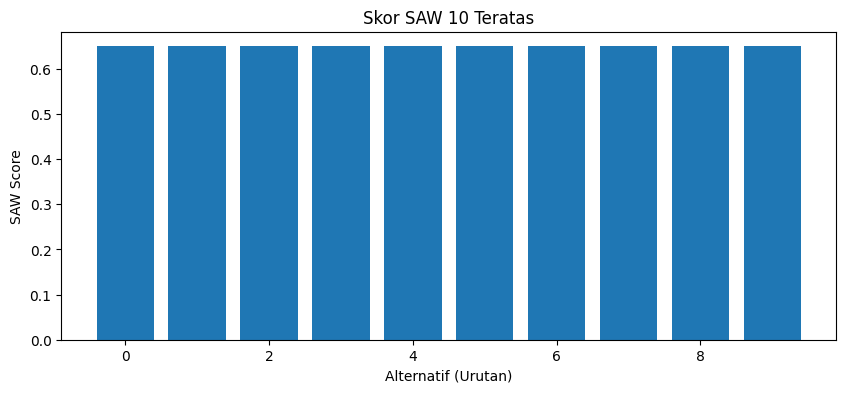

In [ ]:
# ============================================================
# 5. VISUALISASI TABEL KEPUTUSAN SAW
# ============================================================
import matplotlib.pyplot as plt
print('Tabel Keputusan SAW (10 teratas)')
display(df_saw.head(10))
plt.figure(figsize=(10,4))
plt.bar(df_saw.head(10).index.astype(str), df_saw['SAW_Score'].head(10))
plt.title('Skor SAW 10 Teratas')
plt.ylabel('SAW Score')
plt.xlabel('Alternatif (Index)')
plt.show()

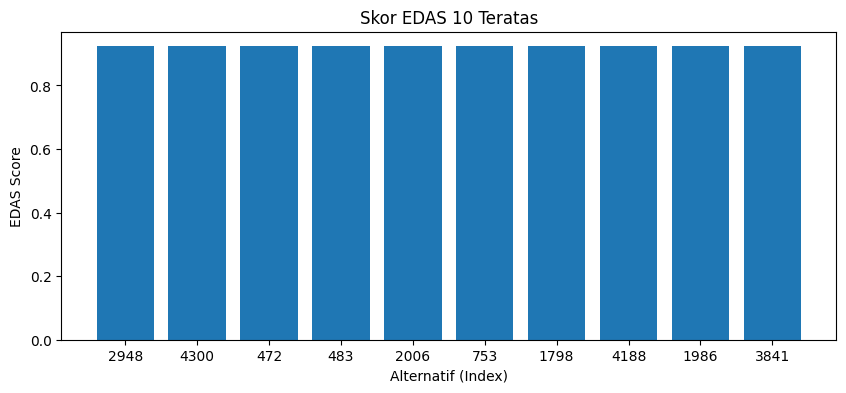

In [11]:
# ============================================================
# 6. TAHAPAN METODE EDAS (Evaluation Based on Distance from Average Solution)
# ============================================================
# 1. Matriks keputusan sudah ada: df_matrix
# 2. Hitung rata-rata tiap kriteria (AV)
AV = np.mean(df_matrix, axis=0)
# 3. Hitung PDA & NDA
def hitung_pda_nda(matrix, AV, kriteria):
    PDA = np.zeros_like(matrix, dtype=float)
    NDA = np.zeros_like(matrix, dtype=float)
    for j in range(matrix.shape[1]):
        if kriteria[j] == 1:  # benefit
            PDA[:, j] = np.maximum(0, (matrix[:, j] - AV[j]) / AV[j])
            NDA[:, j] = np.maximum(0, (AV[j] - matrix[:, j]) / AV[j])
        else:  # cost
            PDA[:, j] = np.maximum(0, (AV[j] - matrix[:, j]) / AV[j])
            NDA[:, j] = np.maximum(0, (matrix[:, j] - AV[j]) / AV[j])
    return PDA, NDA
PDA, NDA = hitung_pda_nda(df_matrix, AV, kriteria)
# 4. Hitung SP & SN
SP = np.dot(PDA, bobot)
SN = np.dot(NDA, bobot)
# 5. Hitung skor akhir (AS)
edas_skor = 0.5 * (SP + (1 - SN))
# 6. Masukkan skor dan ranking ke DataFrame
df_edas = df.copy()
df_edas['EDAS_Score'] = edas_skor
df_edas['Rank_EDAS'] = df_edas['EDAS_Score'].rank(ascending=False, method='min')
df_edas = df_edas.sort_values('Rank_EDAS')
df_edas.head(10)
# 7. Visualisasi Hasil EDAS
plt.figure(figsize=(10,4))
plt.bar(df_edas.head(10).index.astype(str), df_edas['EDAS_Score'].head(10))
plt.title('Skor EDAS 10 Teratas')
plt.ylabel('EDAS Score')
plt.xlabel('Alternatif (Index)')
plt.show()